# E1 Test & Evaluation

**Purpose:** This notebook is for conducting E1 Experiment and processing the experiment's results.

This notebook:

1. Downloads dataset (Roboflow)
2. Downloads COCO pre-trained models (YOLOv8m and RT-DETER-L)
2. Builds evaluation indices
3. Conducting the experiment
4. Generates predictions on test set
5. Runs all 3 evaluation metrics
6. Generates plots


## 0. Setup


### 0.1 Clone Repo to Colab /content

In [1]:
# Check if in Colab
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
    # Clone repo if not already cloned
    import os
    if not os.path.exists('Deep_Learning_Gil_Alon'):
        !git clone https://github.com/gil-attar/Deep_Learning_Project_Gil_Alon.git Deep_Learning_Gil_Alon
    %cd Deep_Learning_Gil_Alon
else:
    print("Running locally")
    import os
    from pathlib import Path
    # Navigate to project root if in notebooks/
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')

print(f"Working directory: {os.getcwd()}")

Running in Google Colab
Cloning into 'Deep_Learning_Gil_Alon'...
remote: Enumerating objects: 605, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 605 (delta 2), reused 2 (delta 1), pack-reused 598 (from 1)
Receiving objects: 100% (605/605), 5.23 MiB | 35.69 MiB/s, done.
Resolving deltas: 100% (344/344), done.
/content/Deep_Learning_Gil_Alon
Working directory: /content/Deep_Learning_Gil_Alon


### 0.2 Mounting Google Drive & Setting up Folder Structure for Results

In [2]:
# Mount Google Drive for saving run results
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import time
from pathlib import Path

PROJECT_NAME = "Deep_Learning_Project_Gil_Alon"

# IMPORTANT:
# - For a fresh folder each time, keep the timestamp.
# - To continue the SAME sweep after a disconnect, set RUN_ID to a fixed string
#   (e.g., RUN_ID="E1_fullsweep_50ep_v1") and reuse it after reconnect.
RUN_ID = time.strftime("E1_%Y%m%d_%H%M%S")

DRIVE_ROOT = Path("/content/drive/MyDrive/Colab_Outputs") / PROJECT_NAME / RUN_ID

PERSIST_E1_RUNS = DRIVE_ROOT / "E1_runs"       # where Experiment 1 outputs will live
PERSIST_WEIGHTS = DRIVE_ROOT / "pretrained"    # optional cache for pretrained weights

PERSIST_E1_RUNS.mkdir(parents=True, exist_ok=True)
PERSIST_WEIGHTS.mkdir(parents=True, exist_ok=True)

print("Drive root:", DRIVE_ROOT)
print("E1 runs:", PERSIST_E1_RUNS)
print("Weights cache:", PERSIST_WEIGHTS)


Drive root: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013
E1 runs: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs
Weights cache: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/pretrained


### 0.3 Symlink the repo’s runs/ to Drive

In [4]:
from pathlib import Path

REPO = Path.cwd()
print("REPO =", REPO)

E1_RUNS_IN_REPO = REPO / "experiments" / "Experiment_1" / "runs"

# Safety check
assert REPO.exists(), f"Repo path does not exist: {REPO}"

# Remove local runs dir if it exists, then link to Drive
!rm -rf "{E1_RUNS_IN_REPO}"
!ln -s "{PERSIST_E1_RUNS}" "{E1_RUNS_IN_REPO}"

print("Symlink created:")
!ls -la "{E1_RUNS_IN_REPO}"


REPO = /content/Deep_Learning_Gil_Alon
Symlink created:
lrwxrwxrwx 1 root root 94 Jan 21 10:10 /content/Deep_Learning_Gil_Alon/experiments/Experiment_1/runs -> /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs


#### 0.4 Re-routing Model Weights to Drive

In [5]:
WEIGHTS_IN_REPO = REPO / "artifacts" / "weights"

!rm -rf "{WEIGHTS_IN_REPO}"
!ln -s "{PERSIST_WEIGHTS}" "{WEIGHTS_IN_REPO}"

print("Weights dir now points to Drive:")
!ls -la "{WEIGHTS_IN_REPO}"


Weights dir now points to Drive:
lrwxrwxrwx 1 root root 97 Jan 21 10:10 /content/Deep_Learning_Gil_Alon/artifacts/weights -> /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/pretrained


In [6]:
# Install dependencies
!pip install -q ultralytics roboflow pyyaml pillow numpy matplotlib pandas tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 140.6 MB/s eta 0:00:00


In [7]:
# Check GPU
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


## 1. Download Dataset

In [8]:
# Set Roboflow API key
import os
os.environ["ROBOFLOW_API_KEY"] = "zEF9icmDY2oTcPkaDcQY"  # Your API key

# Download dataset
!python scripts/download_dataset.py --output_dir data/raw

DOWNLOADING FOOD INGREDIENTS DATASET
  Workspace: gaworkspace-utcbg
  Project:   food-ingredients-dataset-2-rewtd
  Version:   1
  Output:    data/raw
loading Roboflow workspace...
loading Roboflow project...


Extracting Dataset Version Zip to FOOD-INGREDIENTS-dataset-2-1 in yolov8:: 100% 3980/3980 [00:00<00:00, 7258.71it/s]
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Downloaded to: /content/Deep_Learning_Gil_Alon/FOOD-INGREDIENTS-dataset-2-1
  Moved train/
  Moved valid/
  Moved test/
  Copied data.yaml

DOWNLOAD COMPLETE
  train: 1384 images
  valid: 200 images
  test: 400 images

✓ Dataset saved to data/raw

IMPORTANT: data/raw/ is READ-ONLY. Never modify these files.

Next step: Run build_evaluation_index.py to create 

In [9]:
# Verify dataset downloaded
!echo "Train images: $(ls data/raw/train/images/ 2>/dev/null | wc -l)"
!echo "Valid images: $(ls data/raw/valid/images/ 2>/dev/null | wc -l)"
!echo "Test images: $(ls data/raw/test/images/ 2>/dev/null | wc -l)"

Train images: 1384
Valid images: 200
Test images: 400


## 2. Fetch COCO-Pretrained Weights (YOLOv8m + RT-DETR-L)

Will be stored under `artifacts/weights/`.


In [10]:
# Fetch pretrained weights (idempotent)
!bash scripts/fetch_weights.sh


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 49.7M  100 49.7M    0     0  57.9M      0 --:--:-- --:--:-- --:--:-- 57.9M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 63.4M  100 63.4M    0     0  39.0M      0  0:00:01  0:00:01 --:--:-- 66.7M
OK: weights are present under artifacts/weights/
lrwxrwxrwx 1 root root 97 Jan 21 10:10 artifacts/weights -> /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/pretrained


## 3. Build Evaluation Indices

In [11]:
# Build train/val/test indices (with ACTUAL image dimensions - this is critical!)
# Remove old indices first to ensure fresh rebuild
import shutil
from pathlib import Path

if Path("data/processed/evaluation").exists():
    shutil.rmtree("data/processed/evaluation")
    print("✓ Removed old indices")

!python scripts/build_evaluation_indices.py \
    --dataset_root data/raw \
    --output_dir data/processed/evaluation

✓ Removed old indices
BUILD EVALUATION INDICES (Train/Val/Test)
Dataset root: data/raw
Output dir:   data/processed/evaluation

Loaded 26 classes from data.yaml

Processing train split: 1384 images...
✓ Saved train_index.json
  - Images: 1384
  - Objects: 3114
  - Difficulty: {'easy': 1078, 'medium': 202, 'hard': 104}

Processing valid split: 200 images...
✓ Saved val_index.json
  - Images: 200
  - Objects: 476
  - Difficulty: {'easy': 149, 'medium': 31, 'hard': 20}

Processing test split: 400 images...
✓ Saved test_index.json
  - Images: 400
  - Objects: 856
  - Difficulty: {'easy': 313, 'medium': 50, 'hard': 37}

✓ All evaluation indices created!

Generated files in data/processed/evaluation/:
  - train_index.json
  - val_index.json
  - test_index.json

These files are now FROZEN for reproducibility.
Do not regenerate unless absolutely necessary.


In [12]:
# Verify indices created
import json
from pathlib import Path

test_index_path = "data/processed/evaluation/test_index.json"

if Path(test_index_path).exists():
    with open(test_index_path) as f:
        test_data = json.load(f)
    print(f"✓ Test index: {test_data['metadata']['num_images']} images")
    print(f"  Total objects: {test_data['metadata']['total_objects']}")
    print(f"  Classes: {test_data['metadata']['num_classes']}")
else:
    print(f"❌ Test index not found!")

✓ Test index: 400 images
  Total objects: 856
  Classes: 26


### 3.1. Create data.yaml for Training

In [13]:
# Create data.yaml with absolute paths for Colab
import yaml
from pathlib import Path
import os

# Get absolute path to dataset
dataset_root = Path('data/raw').resolve()

# Read original data.yaml to get class names
with open(dataset_root / 'data.yaml', 'r') as f:
    config = yaml.safe_load(f)

# Create config with ABSOLUTE paths
train_config = {
    'path': str(dataset_root),  # Absolute base path
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'names': config['names'],
    'nc': len(config['names'])
}

# Save to data/processed/
output_path = Path('data/processed/data.yaml')
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, 'w') as f:
    yaml.dump(train_config, f, default_flow_style=False, sort_keys=False)

print(f"✓ Created data.yaml with absolute paths")
print(f"  Path: {train_config['path']}")
print(f"  Classes: {train_config['nc']}")

✓ Created data.yaml with absolute paths
  Path: /content/Deep_Learning_Gil_Alon/data/raw
  Classes: 26


## 4. Run Experiment 1 (Freeze Ladder: YOLOv8m vs RT-DETR-L)

This section runs the full E1 sweep using the experiments runner scripts.
then, per run train, export predictions, and run the custom evaluator.


In [14]:
# E1 sweep configuration
DRY_RUN = False   # True for quick testing: 1 epoch for each of the 8 runs. False for the real sweep.
EPOCHS  = 1 if DRY_RUN else 50
IMGSZ   = 640
SEED    = 42

print(f"DRY_RUN={DRY_RUN} | EPOCHS={EPOCHS} | IMGSZ={IMGSZ} | SEED={SEED}")


DRY_RUN=False | EPOCHS=50 | IMGSZ=640 | SEED=42


In [15]:
# Run the full E1 matrix (8 runs)
# This calls experiments/Experiment_1/runOneTest.py for each (model, freeze_id).
!EPOCHS={EPOCHS} IMGSZ={IMGSZ} SEED={SEED} bash experiments/Experiment_1/run_experiment1.sh


[INFO] CUDA_VISIBLE_DEVICES=0
[INFO] nvidia-smi available; GPU status:
[KEEPALIVE] 2026-01-21 10:10:45 UTC still running...
Wed Jan 21 10:10:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   36C    P0             54W /  400W |       5MiB /  81920MiB |      0%      Default |
|               

## 5. Verify Run Outputs

Sanity checks: verify that each run directory contains manifests, predictions, and evaluation outputs.


In [32]:
from pathlib import Path
import json

runs_root = Path("/content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs")
assert runs_root.exists(), f"Missing runs root: {runs_root}"

# Contract-required artifacts (RUN_CONTRACT.md)
required_files = [
    "run_manifest.json",
    "run_summary.json",
    "train_summary.json",
    "predictions/val_predictions.json",
    "predictions/test_predictions.json",
    "eval/val/metrics.json",
    "eval/val/summary.csv",
    "eval/test/metrics.json",
    "eval/test/summary.csv",
    "weights/best.pt",
    "weights/last.pt",
    # plots live under eval/<split>/plots/
    "eval/val/plots/threshold_sweep.png",
    "eval/val/plots/per_class_f1.png",
    "eval/val/plots/confusion_matrix.png",
    "eval/val/plots/count_mae_comparison.png",
    "eval/test/plots/threshold_sweep.png",
    "eval/test/plots/per_class_f1.png",
    "eval/test/plots/confusion_matrix.png",
    "eval/test/plots/count_mae_comparison.png",
]

# args.yaml location can vary. We accept any of these as satisfying the contract's
# "ultralytics/args.yaml (or a copied snapshot of args)" requirement.
args_yaml_candidates = [
    "ultralytics/args.yaml",
    "args.yaml",
]

def has_any_args_yaml(run_dir: Path) -> bool:
    return any((run_dir / rel).exists() for rel in args_yaml_candidates)

run_dirs = sorted([p for p in runs_root.glob("**/F[0-3]") if p.is_dir()])
print(f"Found {len(run_dirs)} run directories")

missing = []
for rd in run_dirs:
    for rel in required_files:
        if not (rd / rel).exists():
            missing.append((str(rd), rel))
    if not has_any_args_yaml(rd):
        missing.append((str(rd), "(args.yaml missing: expected one of ultralytics/args.yaml or args.yaml)"))

if missing:
    print("WARNING: missing required artifacts in some runs:")
    for rd, rel in missing[:200]:
        print(f"  - {rd} :: {rel}")
    print(f"Total missing entries: {len(missing)}")
else:
    print("✓ All runs satisfy the contract-required artifact set.")


Found 8 run directories
✓ All runs satisfy the contract-required artifact set.


## 6. Aggregate Metrics Across Runs

Build a single table across the 8 runs, reading `run_manifest.json`, `eval/test/metrics.json`, and the predictions timing metadata.


In [33]:
### THIS CODE CELL IS AFTER THE EDIT ###

import pandas as pd
import numpy as np
from pathlib import Path

def find_results_csv(run_dir: Path) -> Path:
    """
    Ultralytics typically writes: <run_dir>/results.csv
    We also support fallback searches.
    """
    direct = run_dir / "results.csv"
    if direct.exists():
        return direct

    # fallback: sometimes results*.csv exists
    cands = list(run_dir.glob("results*.csv")) + list(run_dir.rglob("results*.csv"))
    cands = [p for p in cands if p.is_file()]
    if not cands:
        raise FileNotFoundError(f"No results.csv found under: {run_dir}")

    # pick the shortest path (usually the main one), then newest
    cands.sort(key=lambda p: (len(str(p)), -p.stat().st_mtime))
    return cands[0]

def load_epoch_log(run_dir: Path) -> pd.DataFrame:
    csv_path = find_results_csv(run_dir)
    df = pd.read_csv(csv_path)

    # Normalize column names (strip whitespace)
    df.columns = [c.strip() for c in df.columns]

    # Ensure epoch exists
    if "epoch" not in df.columns:
        # sometimes epoch is implicit index
        df.insert(0, "epoch", np.arange(len(df)))

    return df

def pick_first_existing_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None

def get_map50_col(df: pd.DataFrame) -> str | None:
    # Common Ultralytics naming variants
    candidates = [
        "metrics/mAP50(B)", "metrics/mAP50", "metrics/mAP_0.5",
        "metrics/mAP50-95(B)",  # not map50, but used as fallback
        "metrics/mAP50(M)",     # if masks exist (unlikely here)
    ]
    c = pick_first_existing_col(df, candidates)
    return c

def get_lr_cols(df: pd.DataFrame) -> list[str]:
    # Ultralytics often logs lr/pg0, lr/pg1, lr/pg2
    return [c for c in df.columns if c.startswith("lr/")]

def get_train_loss_cols(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns if c.startswith("train/") and "loss" in c]

def get_val_loss_cols(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns if c.startswith("val/") and "loss" in c]

# Load per-epoch logs for all discovered runs
epoch_logs = {}  # key: (model, freeze_id) -> DataFrame
for rd in run_dirs:
    model = rd.parts[-2]
    freeze_id = rd.parts[-1]
    try:
        epoch_logs[(model, freeze_id)] = load_epoch_log(rd)
    except Exception as e:
        print(f"[WARN] Could not load epoch log for {model}/{freeze_id}: {e}")

print(f"Loaded epoch logs: {len(epoch_logs)} / {len(run_dirs)} runs")
list(epoch_logs.keys())[:10]


Loaded epoch logs: 8 / 8 runs


[('rtdetr-l', 'F0'),
 ('rtdetr-l', 'F1'),
 ('rtdetr-l', 'F2'),
 ('rtdetr-l', 'F3'),
 ('yolov8m', 'F0'),
 ('yolov8m', 'F1'),
 ('yolov8m', 'F2'),
 ('yolov8m', 'F3')]

In [39]:
import json
import math
import pandas as pd
import numpy as np

def _safe_get(d, keys, default=None):
    cur = d
    for k in keys:
        if not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur

def auc_trapz(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 2:
        return np.nan
    return float(np.trapz(y, x))

# ---- Param count extraction (robust across old/new manifests) ----
def get_param_counts(run_dir, run_manifest):
    def normalize(pc: dict):
        if not isinstance(pc, dict):
            return {}
        # If already in expected format, keep it
        if ("total_params" in pc) or ("trainable_params" in pc):
            return pc
        # Your freeze_debug.json uses {total, trainable}
        if ("total" in pc) or ("trainable" in pc):
            return {
                "total_params": pc.get("total"),
                "trainable_params": pc.get("trainable"),
            }
        return pc

    # 1) Preferred: run_manifest.json["param_counts"]
    pc = _safe_get(run_manifest, ["param_counts"], default=None)
    pc = normalize(pc)
    if isinstance(pc, dict) and ("total_params" in pc or "trainable_params" in pc):
        return pc

    # 2) Some versions: run_manifest.json["effective"]["param_counts"]
    pc = _safe_get(run_manifest, ["effective", "param_counts"], default=None)
    pc = normalize(pc)
    if isinstance(pc, dict) and ("total_params" in pc or "trainable_params" in pc):
        return pc

    # 3) Fallback: freeze_debug.json["param_counts"]
    fd_path = run_dir / "freeze_debug.json"
    if fd_path.exists():
        try:
            fd = json.loads(fd_path.read_text())
            pc = _safe_get(fd, ["param_counts"], default=None)
            pc = normalize(pc)
            if isinstance(pc, dict) and ("total_params" in pc or "trainable_params" in pc):
                return pc
        except Exception:
            pass

    # 4) Fallback: run_summary.json may store param_counts directly or nested
    rs_path = run_dir / "run_summary.json"
    if rs_path.exists():
        try:
            rs = json.loads(rs_path.read_text())
            for keys in [
                ["manifest", "param_counts"],
                ["param_counts"],
                ["effective", "param_counts"],
            ]:
                pc = _safe_get(rs, keys, default=None)
                pc = normalize(pc)
                if isinstance(pc, dict) and ("total_params" in pc or "trainable_params" in pc):
                    return pc
        except Exception:
            pass

    return {}

rows = []
for rd in run_dirs:
    parts = rd.parts
    model = parts[-2]
    freeze_id = parts[-1]

    manifest = json.loads((rd / "run_manifest.json").read_text())
    test_metrics = json.loads((rd / "eval/test/metrics.json").read_text())
    preds_test = json.loads((rd / "predictions/test_predictions.json").read_text())

    pc = get_param_counts(rd, manifest)

    # Per-epoch log (Ultralytics)
    ep = epoch_logs.get((model, freeze_id))
    map50_col = None
    best_val_map50 = np.nan
    best_epoch = np.nan
    epoch_to_90pct = np.nan
    auc_map50 = np.nan

    train_loss_cols, val_loss_cols = [], []
    best_train_loss = np.nan
    best_val_loss = np.nan
    gen_gap_at_best = np.nan

    if ep is not None and len(ep) > 0:
        map50_col = get_map50_col(ep)
        if map50_col is not None:
            y = ep[map50_col].astype(float).to_numpy()
            x = ep["epoch"].astype(float).to_numpy()

            best_epoch = int(ep.loc[np.nanargmax(y), "epoch"])
            best_val_map50 = float(np.nanmax(y))
            auc_map50 = auc_trapz(x, y)

            target = 0.9 * best_val_map50
            idxs = np.where(y >= target)[0]
            if len(idxs) > 0:
                epoch_to_90pct = int(ep.loc[idxs[0], "epoch"])

        train_loss_cols = get_train_loss_cols(ep)
        val_loss_cols = get_val_loss_cols(ep)

        if train_loss_cols:
            ep["_train_total_loss"] = ep[train_loss_cols].sum(axis=1)
        if val_loss_cols:
            ep["_val_total_loss"] = ep[val_loss_cols].sum(axis=1)

        if (train_loss_cols and val_loss_cols and not math.isnan(best_epoch)):
            row = ep[ep["epoch"] == best_epoch]
            if len(row) == 0:
                row = ep.iloc[[int(np.nanargmax(ep[map50_col].astype(float).to_numpy()))]]
            best_train_loss = float(row["_train_total_loss"].iloc[0])
            best_val_loss = float(row["_val_total_loss"].iloc[0])
            gen_gap_at_best = float(best_val_loss - best_train_loss)

    def extract_primary_metric_contract(metrics_json: dict):
        sel = _safe_get(metrics_json, ["selected_conf_threshold"])
        sweep = _safe_get(metrics_json, ["threshold_sweep"], default={})

        if sel is None or not isinstance(sweep, dict) or len(sweep) == 0:
            return None, None, None

        try:
            sel_f = float(sel)
        except Exception:
            return None, None, None

        candidates = [str(sel_f), f"{sel_f:.1f}", f"{sel_f:.2f}", sel]
        entry = None
        for k in candidates:
            if k in sweep:
                entry = sweep[k]
                break
        if entry is None:
            try:
                keys = [(float(k), k) for k in sweep.keys()]
                keys.sort(key=lambda t: abs(t[0] - sel_f))
                entry = sweep[keys[0][1]]
            except Exception:
                return None, None, sel_f

        f1 = entry.get("f1") if isinstance(entry, dict) else None
        if isinstance(f1, (int, float)):
            return "f1_at_selected_threshold", float(f1), sel_f

        return None, None, sel_f

    primary_metric_name, primary_metric_val, selected_thr = extract_primary_metric_contract(test_metrics)

    rows.append({
        "model": model,
        "freeze_id": freeze_id,
        "trainable_params": _safe_get(pc, ["trainable_params"], default=None),
        "total_params": _safe_get(pc, ["total_params"], default=None),
        "map50_col": map50_col,
        "best_val_map50": best_val_map50,
        "best_epoch": best_epoch,
        "epoch_to_90pct_best": epoch_to_90pct,
        "auc_val_map50": auc_map50,
        "best_train_loss_at_best_epoch": best_train_loss,
        "best_val_loss_at_best_epoch": best_val_loss,
        "gen_gap_val_minus_train_at_best": gen_gap_at_best,
        "primary_metric_name": primary_metric_name,
        "primary_metric_test": primary_metric_val,
        "selected_thr_test": selected_thr,
        "avg_inference_time_ms": _safe_get(preds_test, ["timing", "avg_inference_time_ms"]),
        "num_images": _safe_get(preds_test, ["timing", "num_images"]),
    })

df = pd.DataFrame(rows).sort_values(["model", "freeze_id"])
display(df)


/tmp/ipython-input-2375298619.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipython-input-2375298619.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipython-input-2375298619.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipython-input-2375298619.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipython-input-2375298619.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return fl

,model,freeze_id,trainable_params,total_params,map50_col,best_val_map50,best_epoch,epoch_to_90pct_best,auc_val_map50,best_train_loss_at_best_epoch,best_val_loss_at_best_epoch,gen_gap_val_minus_train_at_best,primary_metric_name,primary_metric_test,selected_thr_test,avg_inference_time_ms,num_images
0,rtdetr-l,F0,7355282,32859506,metrics/mAP50(B),0.20479,42,35,6.009020,2.24813,2.34381,0.09568,f1_at_selected_threshold,0.3029,0.4,29.1332,400
1,rtdetr-l,F1,17991570,32859506,metrics/mAP50(B),0.27008,44,37,7.820820,2.11566,2.15299,0.03733,f1_at_selected_threshold,0.3652,0.3,27.4392,400
2,rtdetr-l,F2,19306130,32859506,metrics/mAP50(B),0.30459,41,32,9.137975,2.02206,2.09465,0.07259,f1_at_selected_threshold,0.4407,0.4,27.6056,400
3,rtdetr-l,F3,32859506,32859506,metrics/mAP50(B),0.50658,50,35,14.571730,1.66950,2.00231,0.33281,f1_at_selected_threshold,0.6082,0.4,27.5436,400
4,yolov8m,F0,3790750,25871374,metrics/mAP50(B),0.35841,38,19,14.412405,5.28173,5.84733,0.56560,f1_at_selected_threshold,0.4463,0.2,25.1564,400
5,yolov8m,F1,14015518,25871374,metrics/mAP50(B),0.61433,40,25,24.606870,3.79848,4.60368,0.80520,f1_at_selected_threshold,0.6269,0.2,24.6822,400
6,yolov8m,F2,18832606,25871374,metrics/mAP50(B),0.63484,37,23,25.991855,3.56182,4.39761,0.83579,f1_at_selected_threshold,0.6704,0.2,24.5887,400
7,yolov8m,F3,25871374,25871374,metrics/mAP50(B),0.68692,38,19,28.151605,3.16830,4.27255,1.10425,f1_at_selected_threshold,0.7058,0.3,24.7368,400


## 7. Plots

Key plots for E1:
1. Best Validation mAP@0.5 vs. Trainable Parameters (Freeze Ladder Curve)
2. Speed–Accuracy Tradeoff: mAP@0.5 vs. Avg Inference Time (ms/image)
3. Per-Model Training Loss vs. Epoch (F0–F3 Overlay)
4. Per-Model Validation Loss vs. Epoch (F0–F3 Overlay)
5. Per-Model Validation mAP@0.5 vs. Epoch (F0–F3 Overlay)
6. Cross-Model Validation mAP@0.5 vs. Epoch (YOLO vs RT-DETR, per Freeze Regime)
7. Generalization Gap vs. Freeze Regime (Val Loss − Train Loss at Best Epoch)
8. Convergence Speed vs. Freeze Regime (Epoch to 90% of Best Val mAP@0.5)
9. Learning Rate Schedule vs. Epoch (Representative Runs)


Saved: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/rtdetr-l_train_loss_overlay.png and /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/rtdetr-l_train_loss_overlay.pdf


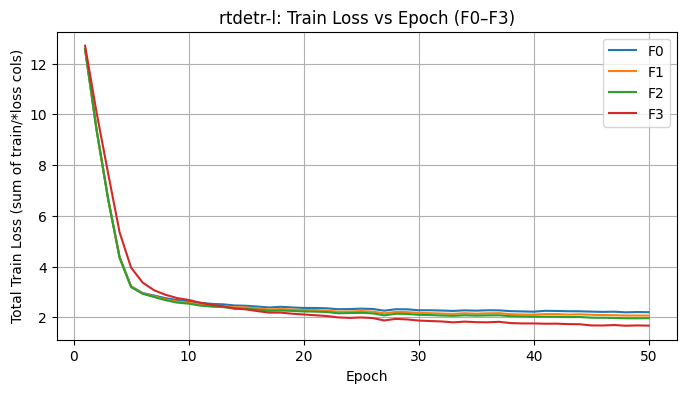

Saved: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/rtdetr-l_val_loss_overlay.png and /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/rtdetr-l_val_loss_overlay.pdf


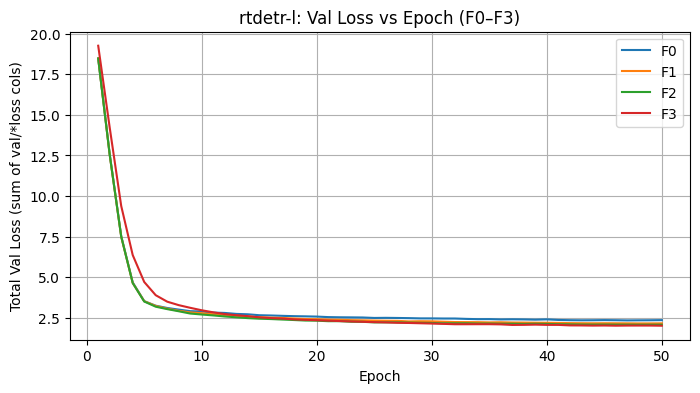

Saved: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/yolov8m_train_loss_overlay.png and /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/yolov8m_train_loss_overlay.pdf


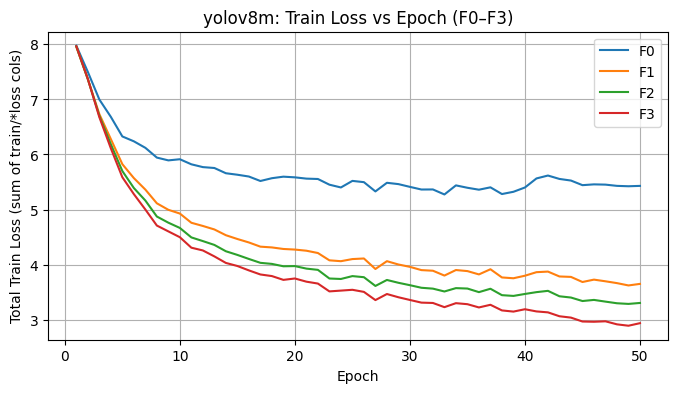

Saved: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/yolov8m_val_loss_overlay.png and /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/yolov8m_val_loss_overlay.pdf


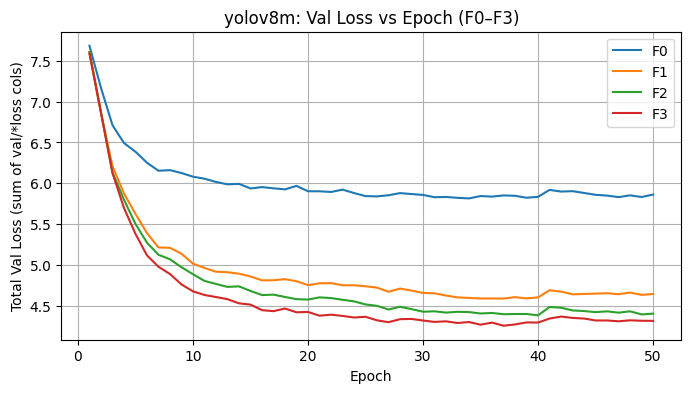

Saved: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/cross_model_map50_F0.png and /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/cross_model_map50_F0.pdf


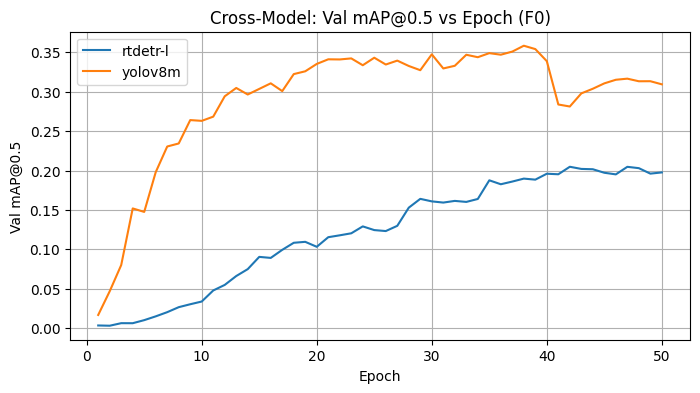

Saved: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/cross_model_map50_F1.png and /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/cross_model_map50_F1.pdf


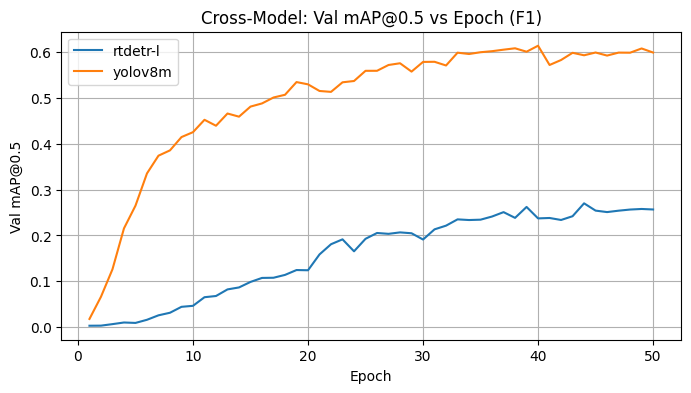

Saved: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/cross_model_map50_F2.png and /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/cross_model_map50_F2.pdf


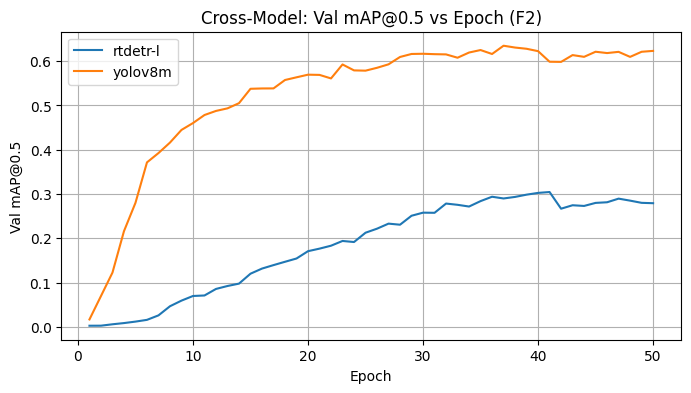

Saved: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/cross_model_map50_F3.png and /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/cross_model_map50_F3.pdf


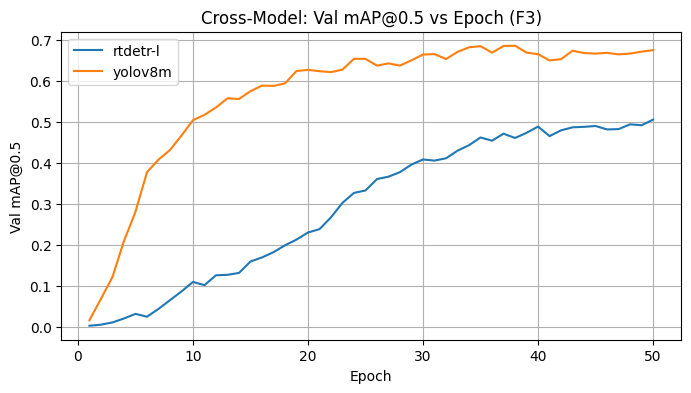

Saved: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/best_map50_vs_trainable_params.png and /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/best_map50_vs_trainable_params.pdf


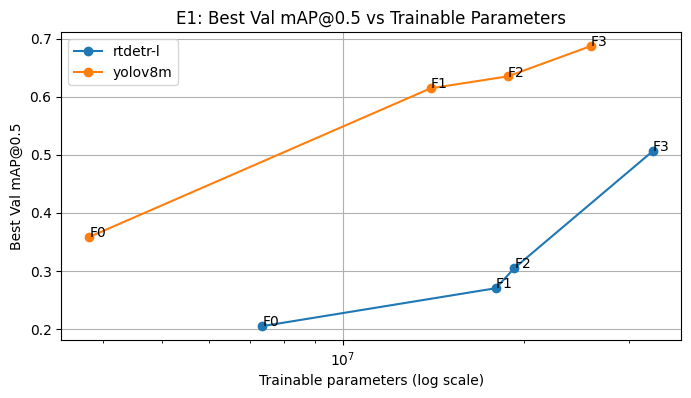

Saved: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/generalization_gap_vs_freeze.png and /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/generalization_gap_vs_freeze.pdf


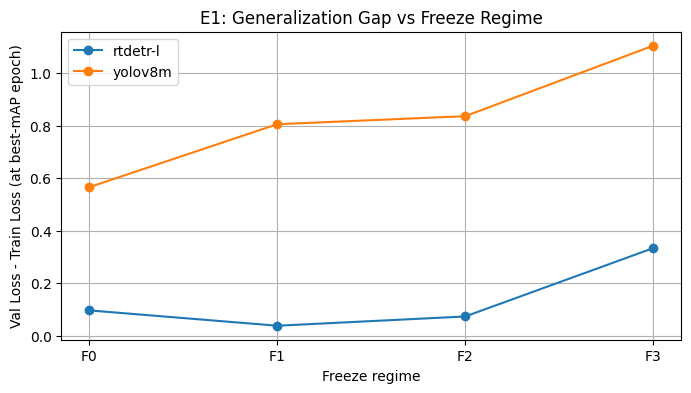

Saved: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/convergence_speed_vs_freeze.png and /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/convergence_speed_vs_freeze.pdf


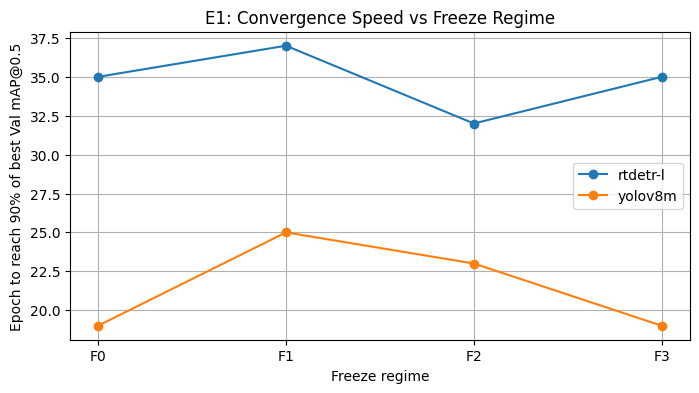

Saved: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/rtdetr-l_F0_lr.png and /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/rtdetr-l_F0_lr.pdf


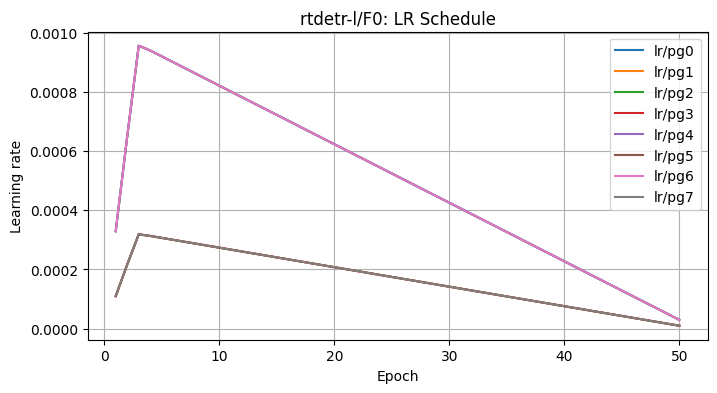

Saved: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/rtdetr-l_F0_map50.png and /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots/rtdetr-l_F0_map50.pdf


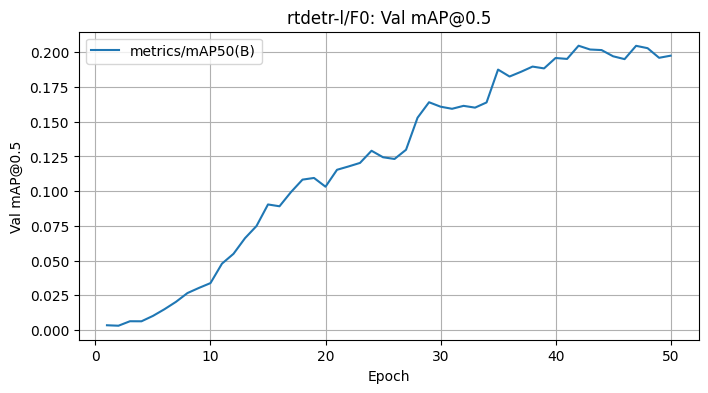

All plots saved under: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots


In [42]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

runs_root = Path("/content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs")
PLOTS_DIR = runs_root / "_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name: str):
    png = PLOTS_DIR / f"{name}.png"
    pdf = PLOTS_DIR / f"{name}.pdf"
    plt.savefig(png, bbox_inches="tight", dpi=200)
    plt.savefig(pdf, bbox_inches="tight")
    print(f"Saved: {png} and {pdf}")

def get_run_df(model: str, freeze_id: str):
    return epoch_logs.get((model, freeze_id))

def plot_loss_overlays_for_model(model: str):
    # Plot (1): loss curves vs epoch, overlay F0-F3
    freezes = sorted([f for (m, f) in epoch_logs.keys() if m == model])
    if not freezes:
        print(f"[SKIP] No epoch logs for model={model}")
        return

    # Total train loss
    plt.figure(figsize=(8,4))
    for fz in freezes:
        ep = get_run_df(model, fz).copy()
        train_cols = get_train_loss_cols(ep)
        if not train_cols:
            continue
        ep["_train_total_loss"] = ep[train_cols].sum(axis=1)
        plt.plot(ep["epoch"], ep["_train_total_loss"], label=fz)
    plt.xlabel("Epoch")
    plt.ylabel("Total Train Loss (sum of train/*loss cols)")
    plt.title(f"{model}: Train Loss vs Epoch (F0–F3)")
    plt.grid(True)
    plt.legend()
    savefig(f"{model}_train_loss_overlay")
    plt.show()

    # Total val loss (if exists)
    plt.figure(figsize=(8,4))
    any_val = False
    for fz in freezes:
        ep = get_run_df(model, fz).copy()
        val_cols = get_val_loss_cols(ep)
        if not val_cols:
            continue
        any_val = True
        ep["_val_total_loss"] = ep[val_cols].sum(axis=1)
        plt.plot(ep["epoch"], ep["_val_total_loss"], label=fz)
    if any_val:
        plt.xlabel("Epoch")
        plt.ylabel("Total Val Loss (sum of val/*loss cols)")
        plt.title(f"{model}: Val Loss vs Epoch (F0–F3)")
        plt.grid(True)
        plt.legend()
        savefig(f"{model}_val_loss_overlay")
        plt.show()
    else:
        plt.close()
        print(f"[INFO] No val/*loss columns logged for model={model}.")

def plot_map_overlays_for_model(model: str):
    # helper for plots (2) and (6)
    freezes = sorted([f for (m, f) in epoch_logs.keys() if m == model])
    if not freezes:
        return
    plt.figure(figsize=(8,4))
    any_map = False
    for fz in freezes:
        ep = get_run_df(model, fz)
        map_col = get_map50_col(ep)
        if map_col is None:
            continue
        any_map = True
        plt.plot(ep["epoch"], ep[map_col], label=fz)
    if any_map:
        plt.xlabel("Epoch")
        plt.ylabel("Val mAP@0.5 (from results.csv)")
        plt.title(f"{model}: Val mAP@0.5 vs Epoch (F0–F3)")
        plt.grid(True)
        plt.legend()
        savefig(f"{model}_map50_overlay")
        plt.show()
    else:
        plt.close()
        print(f"[INFO] No mAP column found for model={model}.")

def plot_cross_model_map_per_freeze():
    # Plot (2): compare YOLO vs RT-DETR per freeze regime over epochs
    models = sorted(set(m for (m, _) in epoch_logs.keys()))
    if len(models) < 2:
        print("[SKIP] Need both models present for cross-model plots.")
        return

    freezes = sorted(set(f for (_, f) in epoch_logs.keys()))
    for fz in freezes:
        plt.figure(figsize=(8,4))
        any_curve = False
        for model in models:
            ep = epoch_logs.get((model, fz))
            if ep is None:
                continue
            map_col = get_map50_col(ep)
            if map_col is None:
                continue
            any_curve = True
            plt.plot(ep["epoch"], ep[map_col], label=model)
        if any_curve:
            plt.xlabel("Epoch")
            plt.ylabel("Val mAP@0.5")
            plt.title(f"Cross-Model: Val mAP@0.5 vs Epoch ({fz})")
            plt.grid(True)
            plt.legend()
            savefig(f"cross_model_map50_{fz}")
            plt.show()
        else:
            plt.close()

def plot_perf_vs_trainable_params():
    # Plot (3): best val mAP vs trainable parameters (log scale)
    d = df.copy()
    d = d.dropna(subset=["trainable_params", "best_val_map50"])
    if len(d) == 0:
        print("[SKIP] Missing trainable_params or best_val_map50.")
        return

    plt.figure(figsize=(8,4))
    for model, g in d.groupby("model"):
        g = g.sort_values("trainable_params")
        plt.plot(g["trainable_params"], g["best_val_map50"], marker="o", label=model)
        for _, r in g.iterrows():
            plt.annotate(r["freeze_id"], (r["trainable_params"], r["best_val_map50"]))
    plt.xscale("log")
    plt.xlabel("Trainable parameters (log scale)")
    plt.ylabel("Best Val mAP@0.5")
    plt.title("E1: Best Val mAP@0.5 vs Trainable Parameters")
    plt.grid(True)
    plt.legend()
    savefig("best_map50_vs_trainable_params")
    plt.show()

def plot_generalization_gap():
    # Plot (4): generalization gap at best epoch (val_loss - train_loss)
    d = df.copy()
    d = d.dropna(subset=["gen_gap_val_minus_train_at_best"])
    if len(d) == 0:
        print("[SKIP] No gen gap computed (need train/*loss and val/*loss in results.csv).")
        return

    plt.figure(figsize=(8,4))
    for model, g in d.groupby("model"):
        # order F0-F3 nicely
        g = g.sort_values("freeze_id")
        plt.plot(g["freeze_id"], g["gen_gap_val_minus_train_at_best"], marker="o", label=model)
    plt.xlabel("Freeze regime")
    plt.ylabel("Val Loss - Train Loss (at best-mAP epoch)")
    plt.title("E1: Generalization Gap vs Freeze Regime")
    plt.grid(True)
    plt.legend()
    savefig("generalization_gap_vs_freeze")
    plt.show()

def plot_convergence_speed():
    # Plot (5): epoch to reach 90% of best val mAP
    d = df.copy()
    d = d.dropna(subset=["epoch_to_90pct_best"])
    if len(d) == 0:
        print("[SKIP] No convergence speed computed (need mAP column in results.csv).")
        return

    plt.figure(figsize=(8,4))
    for model, g in d.groupby("model"):
        g = g.sort_values("freeze_id")
        plt.plot(g["freeze_id"], g["epoch_to_90pct_best"], marker="o", label=model)
    plt.xlabel("Freeze regime")
    plt.ylabel("Epoch to reach 90% of best Val mAP@0.5")
    plt.title("E1: Convergence Speed vs Freeze Regime")
    plt.grid(True)
    plt.legend()
    savefig("convergence_speed_vs_freeze")
    plt.show()

def plot_lr_and_map_example(model: str, freeze_id: str):
    # Plot (6): LR curve + mAP curve (same run) — shown as two figures (cleaner than dual axis)
    ep = epoch_logs.get((model, freeze_id))
    if ep is None:
        print(f"[SKIP] Missing epoch log for {model}/{freeze_id}")
        return

    lr_cols = get_lr_cols(ep)
    if not lr_cols:
        print(f"[INFO] No lr/* columns found for {model}/{freeze_id}")
    else:
        plt.figure(figsize=(8,4))
        for c in lr_cols:
            plt.plot(ep["epoch"], ep[c], label=c)
        plt.xlabel("Epoch")
        plt.ylabel("Learning rate")
        plt.title(f"{model}/{freeze_id}: LR Schedule")
        plt.grid(True)
        plt.legend()
        savefig(f"{model}_{freeze_id}_lr")
        plt.show()

    map_col = get_map50_col(ep)
    if map_col is None:
        print(f"[INFO] No mAP column found for {model}/{freeze_id}")
    else:
        plt.figure(figsize=(8,4))
        plt.plot(ep["epoch"], ep[map_col], label=map_col)
        plt.xlabel("Epoch")
        plt.ylabel("Val mAP@0.5")
        plt.title(f"{model}/{freeze_id}: Val mAP@0.5")
        plt.grid(True)
        plt.legend()
        savefig(f"{model}_{freeze_id}_map50")
        plt.show()

# -----------------------------
# Produce plots (1)–(6)
# -----------------------------
models_present = sorted(set(m for (m, _) in epoch_logs.keys()))

# (1) per model loss overlays
for m in models_present:
    plot_loss_overlays_for_model(m)

# (2) cross-model mAP per freeze
plot_cross_model_map_per_freeze()

# (3) best mAP vs trainable params
plot_perf_vs_trainable_params()

# (4) generalization gap
plot_generalization_gap()

# (5) convergence speed
plot_convergence_speed()

# (6) LR + mAP for one representative run (edit selection if you want)
if models_present:
    # choose first available run in epoch_logs
    m0, f0 = list(epoch_logs.keys())[0]
    plot_lr_and_map_example(m0, f0)

print("All plots saved under:", PLOTS_DIR.resolve())


## 8. Display Evaluator plots


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

PLOTS_DIR = Path(PLOTS_DIR)  # ensure Path
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

REL_PNGS = [
    ("threshold_sweep", "eval/test/plots/threshold_sweep.png"),
    ("per_class_f1", "eval/test/plots/per_class_f1.png"),
    ("confusion_matrix", "eval/test/plots/confusion_matrix.png"),
    ("count_mae_comparison", "eval/test/plots/count_mae_comparison.png"),
]

def make_contact_sheet_for_run(run_dir: Path):
    model = run_dir.parts[-2]
    freeze_id = run_dir.parts[-1]
    out_base = f"{model}_{freeze_id}_TEST_plots_contact_sheet"

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    missing = []
    for i, (title, rel) in enumerate(REL_PNGS):
        ax = axes[i]
        p = run_dir / rel
        if p.exists():
            img = mpimg.imread(str(p))
            ax.imshow(img)
            ax.set_title(title)
        else:
            ax.text(0.5, 0.5, f"MISSING\n{rel}", ha="center", va="center")
            ax.set_title(title)
            missing.append(rel)
        ax.axis("off")

    fig.suptitle(f"{model}/{freeze_id} — TEST evaluator plots", fontsize=16)

    png_out = PLOTS_DIR / f"{out_base}.png"
    pdf_out = PLOTS_DIR / f"{out_base}.pdf"
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(png_out, dpi=200, bbox_inches="tight")
    fig.savefig(pdf_out, bbox_inches="tight")
    plt.close(fig)

    return png_out, pdf_out, missing

saved = []
all_missing = []

for rd in run_dirs:
    png_out, pdf_out, missing = make_contact_sheet_for_run(rd)
    saved.append((str(rd), str(png_out), str(pdf_out)))
    if missing:
        all_missing.append((str(rd), missing))

print(f"Saved {len(saved)} contact sheets into: {PLOTS_DIR.resolve()}")
if all_missing:
    print("\nRuns with missing TEST plot files:")
    for rd, miss in all_missing:
        print(f" - {rd}")
        for m in miss:
            print(f"    * {m}")


Saved 8 contact sheets into: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E1_20260121_101013/E1_runs/_plots


## Summary

- Stages 1–3 prepare the dataset, build ground-truth indices, and generate `data/processed/data.yaml`.
- Stage 4 runs E1 (8 runs) using your experiment runner scripts.
- Stages 5–8 verify artifacts and aggregate results into tables and plots suitable for reporting.
